# 2.1 理论计算题解答

---

## 题目条件
输入图像尺寸：$3 \times 32 \times 32$（通道数 × 高 × 宽）
卷积层参数：
- 卷积核数量：16个
- 单个卷积核尺寸：$3 \times 5 \times 5$
- 填充（Padding）：$P=2$
- 步幅（Stride）：$S=2$

---

## 问题1：计算输出特征图尺寸（通道数 × 高 × 宽）

卷积输出尺寸计算公式：
\[
\begin{align*}
C_{\text{out}} &= \text{卷积核数量} \\
H_{\text{out}} &= \left\lfloor \frac{H_{\text{in}} + 2P - K_h}{S} \right\rfloor + 1 \\
W_{\text{out}} &= \left\lfloor \frac{W_{\text{in}} + 2P - K_w}{S} \right\rfloor + 1
\end{align*}
\]

代入参数计算：
- 输出通道数：$C_{\text{out}} = 16$
- 输出高度：
  \[
  H_{\text{out}} = \left\lfloor \frac{32 + 2 \times 2 - 5}{2} \right\rfloor + 1 = \left\lfloor \frac{31}{2} \right\rfloor + 1 = 15 + 1 = 16
  \]
- 输出宽度：
  \[
  W_{\text{out}} = \left\lfloor \frac{32 + 2 \times 2 - 5}{2} \right\rfloor + 1 = 16
  \]

**输出特征图尺寸：$\boldsymbol{16 \times 16 \times 16}$**

---

## 问题2：计算单个输出通道的一个像素值需要的点乘（乘法）操作次数

单个输出像素的乘法操作次数 = 卷积核的参数总数：
\[
\text{乘法次数} = C_{\text{in}} \times K_h \times K_w
\]

代入参数：
\[
3 \times 5 \times 5 = 75
\]

**单个输出通道的一个像素值需要 75 次乘法操作**

---

## 答案汇总
1. 输出特征图尺寸：$\boldsymbol{16 \times 16 \times 16}$
2. 单个输出通道像素的乘法次数：$\boldsymbol{75}$ 次

In [1]:
import numpy as np

def max_pool2d_numpy(x, kernel_size, stride, padding):
    """
    手动实现二维最大池化（NumPy版）
    参数:
        x: 输入特征图，形状 (N, C, H, W)
        kernel_size: 池化核大小，整数或 (kh, kw)
        stride: 步幅，整数或 (sh, sw)
        padding: 填充，整数或 (ph, pw)
    返回:
        out: 池化后的特征图，形状 (N, C, H_out, W_out)
    """
    # 统一参数格式
    if isinstance(kernel_size, int):
        kh, kw = kernel_size, kernel_size
    else:
        kh, kw = kernel_size
    if isinstance(stride, int):
        sh, sw = stride, stride
    else:
        sh, sw = stride
    if isinstance(padding, int):
        ph, pw = padding, padding
    else:
        ph, pw = padding

    N, C, H, W = x.shape

    # 1. 填充输入
    x_pad = np.pad(x,
                   pad_width=((0, 0), (0, 0), (ph, ph), (pw, pw)),
                   mode='constant',
                   constant_values=0)

    # 2. 计算输出尺寸
    H_out = (H + 2 * ph - kh) // sh + 1
    W_out = (W + 2 * pw - kw) // sw + 1

    # 3. 初始化输出
    out = np.zeros((N, C, H_out, W_out), dtype=x.dtype)

    # 4. 滑动窗口取最大值
    for i in range(H_out):
        h_start = i * sh
        h_end = h_start + kh
        for j in range(W_out):
            w_start = j * sw
            w_end = w_start + kw
            # 取窗口内的最大值
            out[:, :, i, j] = np.max(x_pad[:, :, h_start:h_end, w_start:w_end], axis=(2, 3))

    return out


# 测试代码
if __name__ == "__main__":
    # 构造测试输入
    x = np.array([
        [
            [
                [1, 2, 3, 4],
                [5, 6, 7, 8],
                [9, 10, 11, 12],
                [13, 14, 15, 16]
            ]
        ]
    ], dtype=np.float32)  # shape (1,1,4,4)

    # 池化参数
    kernel_size = 2
    stride = 2
    padding = 0

    # 调用自定义池化
    out = max_pool2d_numpy(x, kernel_size, stride, padding)
    print("输入:\n", x.squeeze())
    print("池化输出:\n", out.squeeze())
    # 预期输出: [[6, 8], [14, 16]]

输入:
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]
池化输出:
 [[ 6.  8.]
 [14. 16.]]


# 3.1 理论计算题解答

---

## 题目条件
- 输入和输出特征图通道数均为 $C$
- 所有卷积层均不带偏置（bias）

---

### 问题1：计算一个 $5 \times 5$ 卷积层的参数量

单个卷积层（无偏置）的参数量公式：
\[
\text{参数量} = \text{输入通道数} \times \text{输出通道数} \times \text{卷积核高} \times \text{卷积核宽}
\]

代入参数：
- 输入通道数 = $C$
- 输出通道数 = $C$
- 卷积核大小 = $5 \times 5$

\[
\text{参数量}_{5 \times 5} = C \times C \times 5 \times 5 = 25C^2
\]

**答案：$25C^2$**

---

### 问题2：计算两个串联的 $3 \times 3$ 卷积层的总参数量

- 第1层：输入通道数 $C$，输出通道数 $C$，卷积核 $3 \times 3$
  \[
  \text{参数量}_1 = C \times C \times 3 \times 3 = 9C^2
  \]
- 第2层：输入通道数 $C$，输出通道数 $C$，卷积核 $3 \times 3$
  \[
  \text{参数量}_2 = C \times C \times 3 \times 3 = 9C^2
  \]

总参数量：
\[
\text{总参数量} = \text{参数量}_1 + \text{参数量}_2 = 9C^2 + 9C^2 = 18C^2
\]

**答案：$18C^2$**

---

## 补充对比（可选）
- $5 \times 5$ 卷积参数量：$25C^2$
- 两个 $3 \times 3$ 串联卷积参数量：$18C^2$
- 结论：在感受野相同（均为 $5 \times 5$）的情况下，使用多个小卷积核串联可以显著减少参数量。

In [2]:
import torch
import torch.nn as nn

def nin_block(in_channels, out_channels, kernel_size, stride, padding):
    """
    定义标准 NiN 块
    结构：卷积层 + ReLU → 1x1卷积 + ReLU → 1x1卷积 + ReLU
    """
    return nn.Sequential(
        # 普通卷积层
        nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.ReLU(inplace=True),
        # 第一个 1x1 卷积层
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True),
        # 第二个 1x1 卷积层
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True)
    )


# 测试代码
if __name__ == "__main__":
    # 构造一个 NiN 块，例如：输入3通道，输出96通道，卷积核11x11，步幅4，填充0
    block = nin_block(in_channels=3, out_channels=96, kernel_size=11, stride=4, padding=0)
    print(block)

    # 构造测试输入：(batch_size=1, channels=3, height=224, width=224)
    x = torch.randn(1, 3, 224, 224)
    out = block(x)
    print("输入形状:", x.shape)
    print("输出形状:", out.shape)

Sequential(
  (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
  (1): ReLU(inplace=True)
  (2): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU(inplace=True)
  (4): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU(inplace=True)
)
输入形状: torch.Size([1, 3, 224, 224])
输出形状: torch.Size([1, 96, 54, 54])


# 4.1 理论计算题解答

---

## 题目条件
- 小批量样本：$x_1=2,\ x_2=4,\ x_3=6,\ x_4=8$
- BN层参数：缩放参数 $\gamma=2$，平移参数 $\beta=1$，常数 $\epsilon=0$
- Batch Normalization 公式：
  \[
  y_i = \gamma \cdot \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
  \]
  其中：
  - $\mu = \frac{1}{N}\sum_{i=1}^N x_i$ 为批均值
  - $\sigma^2 = \frac{1}{N}\sum_{i=1}^N (x_i - \mu)^2$ 为批方差
  - $N=4$ 为批量大小

---

## 步骤1：计算批均值 $\mu$
\[
\mu = \frac{2+4+6+8}{4} = \frac{20}{4} = 5
\]

## 步骤2：计算批方差 $\sigma^2$
\[
\begin{align*}
\sigma^2 &= \frac{1}{4}\left[(2-5)^2 + (4-5)^2 + (6-5)^2 + (8-5)^2\right] \\
&= \frac{1}{4}\left[(-3)^2 + (-1)^2 + 1^2 + 3^2\right] \\
&= \frac{1}{4}\left[9 + 1 + 1 + 9\right] \\
&= \frac{20}{4} = 5
\end{align*}
\]

## 步骤3：代入 BN 公式计算输出
因为 $\epsilon=0$，所以 $\sqrt{\sigma^2 + \epsilon} = \sqrt{5}$，
\[
y_i = 2 \cdot \frac{x_i - 5}{\sqrt{5}} + 1
\]

逐个计算：
- $y_1 = 2 \cdot \frac{2-5}{\sqrt{5}} + 1 = 1 - \frac{6}{\sqrt{5}}$
- $y_2 = 2 \cdot \frac{4-5}{\sqrt{5}} + 1 = 1 - \frac{2}{\sqrt{5}}$
- $y_3 = 2 \cdot \frac{6-5}{\sqrt{5}} + 1 = 1 + \frac{2}{\sqrt{5}}$
- $y_4 = 2 \cdot \frac{8-5}{\sqrt{5}} + 1 = 1 + \frac{6}{\sqrt{5}}$

若有理化分母：
- $y_1 = 1 - \frac{6\sqrt{5}}{5}$
- $y_2 = 1 - \frac{2\sqrt{5}}{5}$
- $y_3 = 1 + \frac{2\sqrt{5}}{5}$
- $y_4 = 1 + \frac{6\sqrt{5}}{5}$

---

## 最终答案
\[
\boxed{
\begin{aligned}
y_1 &= 1 - \frac{6\sqrt{5}}{5}, \\
y_2 &= 1 - \frac{2\sqrt{5}}{5}, \\
y_3 &= 1 + \frac{2\sqrt{5}}{5}, \\
y_4 &= 1 + \frac{6\sqrt{5}}{5}
\end{aligned}
}
\]

In [3]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_1x1conv=False):
        """
        残差块定义
        参数:
            in_channels: 输入通道数
            out_channels: 输出通道数
            stride: 步幅（控制特征图尺寸）
            use_1x1conv: 是否使用1x1卷积调整输入通道/尺寸
        """
        super().__init__()
        # 两个 3x3 卷积层，后接 BN
        self.conv1 = nn.Conv2d(in_channels, out_channels, 
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 1x1 卷积调整通道/尺寸（可选）
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels, out_channels, 
                                   kernel_size=1, stride=stride, bias=False)
            self.bn3 = nn.BatchNorm2d(out_channels)
        else:
            self.conv3 = None

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # 主路径
        y = self.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))

        # 残差路径
        if self.conv3 is not None:
            x = self.bn3(self.conv3(x))

        # 残差连接：f(x) + x
        y += x
        y = self.relu(y)
        return y


# 测试代码
if __name__ == "__main__":
    # 测试1：输入输出通道相同，不使用1x1卷积
    block1 = Residual(in_channels=64, out_channels=64, stride=1, use_1x1conv=False)
    x1 = torch.randn(1, 64, 32, 32)
    out1 = block1(x1)
    print("测试1输入形状:", x1.shape)
    print("测试1输出形状:", out1.shape)

    # 测试2：输入输出通道不同，使用1x1卷积调整
    block2 = Residual(in_channels=64, out_channels=128, stride=2, use_1x1conv=True)
    x2 = torch.randn(1, 64, 32, 32)
    out2 = block2(x2)
    print("测试2输入形状:", x2.shape)
    print("测试2输出形状:", out2.shape)

测试1输入形状: torch.Size([1, 64, 32, 32])
测试1输出形状: torch.Size([1, 64, 32, 32])
测试2输入形状: torch.Size([1, 64, 32, 32])
测试2输出形状: torch.Size([1, 128, 16, 16])


# 5.1 理论计算题解答

---

## 问题1：为什么底层特征提取层学习率小，顶层输出层学习率大？

在微调（Fine-tuning）中，学习率的差异设置，本质上是为了**平衡“保留预训练通用知识”和“适配新任务特定知识”**：

1.  **底层特征提取层**
    - 预训练模型的底层卷积层，学习的是通用的、可迁移的基础特征（如边缘、纹理、颜色梯度），这些特征在不同视觉任务中都高度适用。
    - 如果使用大学习率，会大幅更新这些已训练好的参数，破坏预训练学到的通用特征，导致模型“遗忘”基础视觉知识，在目标任务上反而效果变差。
    - 因此通常使用**较小的学习率**，甚至直接冻结参数，让底层特征提取能力尽量保持稳定，仅做微小调整。

2.  **顶层输出层**
    - 顶层全连接层/分类层，是针对源数据集（如ImageNet）的特定类别训练的，与目标数据集的类别完全不匹配，需要重新学习目标任务的分类/映射规则。
    - 这些层的参数是随机初始化或与目标任务无关的，没有可保留的通用知识，需要快速学习目标数据的模式。
    - 因此使用**较大的学习率**，让这些参数能快速向目标任务的最优解收敛。

---

## 问题2：目标数据集很小且与源数据集相似时，如何微调防止过拟合？

当目标数据集规模小、且与源数据集高度相似时，核心目标是**最大化利用预训练模型的通用知识，最小化模型参数的更新幅度**，防止模型快速拟合少量样本的噪声。推荐以下策略：

1.  **冻结全部底层特征提取层，仅训练顶层输出层**
    - 完全不更新预训练模型的卷积层参数，仅将其作为固定的特征提取器，只训练新初始化的分类层。
    - 这样模型的可训练参数极少，不会因为少量样本而快速过拟合，同时又能利用预训练模型的强大特征提取能力。

2.  **使用极小的学习率微调顶层+少量高层卷积层**
    - 如果仅训练分类层效果不佳，可以解冻模型的最后1-2个卷积块，设置**极小的学习率（如1e-5或更小）**进行微调。
    - 底层和大部分高层卷积层保持冻结，仅让模型微调少量与目标任务更相关的高级特征，避免大幅修改预训练权重。

3.  **加入正则化与数据增强**
    - 对目标数据使用数据增强（如随机裁剪、翻转、颜色扰动），扩充有效训练数据，降低过拟合风险。
    - 在训练中加入Dropout、L2权重衰减（Weight Decay）等正则化手段，限制模型的拟合能力。

4.  **早停（Early Stopping）**
    - 使用验证集监控模型性能，当验证集性能不再提升时，提前停止训练，避免模型过度学习训练集的噪声。

---

### 核心思路总结
- 数据集小且相似时，**“少动甚至不动预训练权重，只动新层”**是防过拟合的关键。
- 微调的本质是“迁移知识”，而不是“从头训练”，过度修改预训练权重反而会让模型失去泛化能力。

In [14]:
from torchvision import transforms

# 定义图像增广管道
train_transform = transforms.Compose([
    # 1. 随机裁剪并缩放到 224x224，面积比例 0.08~1.0
    transforms.RandomResizedCrop(
        size=224,
        scale=(0.08, 1.0)
    ),
    # 2. 50% 概率水平翻转
    transforms.RandomHorizontalFlip(p=0.5),
    # 3. 随机调整亮度、对比度、饱和度，变化范围 0.5
    transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.5
    ),
    # 4. 转换为 PyTorch 张量
    transforms.ToTensor()
])

In [15]:
from PIL import Image

# 加载示例图像（PIL 格式）
img = Image.open("example.jpg").convert("RGB")

# 应用增广管道
augmented_img_tensor = train_transform(img)

print("增广后张量形状:", augmented_img_tensor.shape) 

增广后张量形状: torch.Size([3, 224, 224])


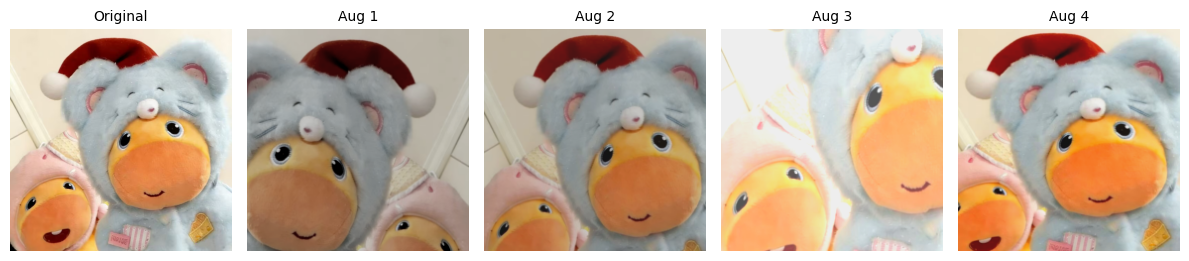

In [16]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. 定义数据增广流水线
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
])

# 2. 读取图片（替换成你本地图片路径）
img_path = "example.jpg"  # 改为你的图片路径
origin_img = Image.open(img_path).convert("RGB")

# 3. 生成多张增广后的图片
aug_imgs = [train_transform(origin_img) for _ in range(4)]

# 4. 可视化展示
plt.figure(figsize=(12, 6))
# 原图
plt.subplot(1, 5, 1)
plt.imshow(origin_img)
plt.title("Original", fontsize=10)
plt.axis("off")

# 增广图
for idx, img in enumerate(aug_imgs):
    plt.subplot(1, 5, idx + 2)
    plt.imshow(img)
    plt.title(f"Aug {idx+1}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

# IoU 计算过程（大白话版）

---

## 题目信息
- 真实框A：`[10, 10, 50, 50]`（左上角坐标、右下角坐标）
- 预测框B：`[30, 30, 70, 70]`

---

## 步骤1：计算两个框各自的面积
1.  真实框A：
    - 宽 = 50 - 10 = 40
    - 高 = 50 - 10 = 40
    - 面积 = 40 × 40 = **1600**

2.  预测框B：
    - 宽 = 70 - 30 = 40
    - 高 = 70 - 30 = 40
    - 面积 = 40 × 40 = **1600**

---

## 步骤2：计算两个框的重叠面积（交集）
重叠区域的坐标：
- 左上角x：取两个框中更靠右的值 → `max(10, 30) = 30`
- 左上角y：取两个框中更靠下的值 → `max(10, 30) = 30`
- 右下角x：取两个框中更靠左的值 → `min(50, 70) = 50`
- 右下角y：取两个框中更靠上的值 → `min(50, 70) = 50`

重叠区域的宽高与面积：
- 宽 = 50 - 30 = 20
- 高 = 50 - 30 = 20
- 重叠面积 = 20 × 20 = **400**

---

## 步骤3：计算两个框合并后的总面积（并集）
并集面积 = 真实框面积 + 预测框面积 - 重叠面积
= 1600 + 1600 - 400
= **2800**

---

## 步骤4：计算IoU（交并比）
IoU = 重叠面积 ÷ 并集面积
= 400 ÷ 2800
= **1/7 ≈ 0.1429**

---

## 最终答案
IoU = 1/7 ≈ 0.1429

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def label_smoothing_cross_entropy(logits, labels, num_classes, epsilon=0.1):
    """
    计算标签平滑后的交叉熵损失
    参数:
        logits: 模型的原始输出（未经过softmax），形状 [N, C]
        labels: 真实标签，形状 [N]，值为0~num_classes-1
        num_classes: 类别数 K
        epsilon: 平滑因子 ε
    返回:
        loss: 标签平滑交叉熵损失（标量）
    """
    # 1. 对logits做softmax
    probs = F.softmax(logits, dim=1)
    
    # 2. 构造平滑后的标签分布
    with torch.no_grad():
        # 错误类别的概率：ε/(K-1)
        wrong_class_prob = epsilon / (num_classes - 1)
        # 正确类别的概率：1 - ε
        smooth_labels = torch.full_like(probs, fill_value=wrong_class_prob)
        smooth_labels.scatter_(1, labels.unsqueeze(1), 1 - epsilon)
    
    # 3. 计算交叉熵：-Σ(p_smooth * log(p_model))
    loss = -torch.sum(smooth_labels * torch.log(probs), dim=1).mean()
    return loss


# 测试代码
if __name__ == "__main__":
    # 模拟数据
    batch_size = 4
    num_classes = 5
    logits = torch.randn(batch_size, num_classes)
    labels = torch.randint(0, num_classes, (batch_size,))

    # 计算损失
    loss = label_smoothing_cross_entropy(logits, labels, num_classes, epsilon=0.1)
    print("标签平滑交叉熵损失:", loss.item())

标签平滑交叉熵损失: 1.1473106145858765
